

```
# This is formatted as code
```

Name - Prateek Rai
Roll no- 202401100300179


In [13]:
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from numpy import log # Not used in current code, but kept for consistency if log transformation is intended later.
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from pandas import read_csv # Explicitly importing read_csv from pandas
import multiprocessing as mp # Not used in current code

### Suppress warnings for cleaner output during execution.
import warnings
warnings.filterwarnings("ignore")


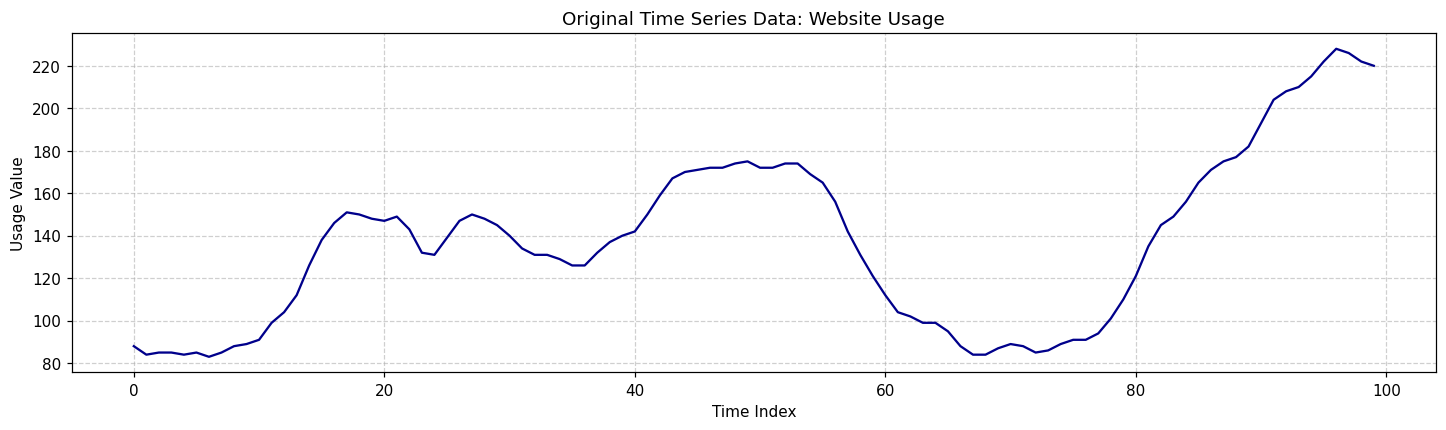

In [14]:
# We're using a sample data from https://raw.githubusercontent.com/selva86/datasets/master/wwwusage.csv
# Import the time series data into a pandas DataFrame
time_series_data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/wwwusage.csv', names=['value'], header=0)

# Visualize the original time series data
plt.figure(figsize=(16, 4)) # Slightly adjusted figure size
plt.plot(time_series_data['value'], color='darkblue') # Added color for the plot
plt.title('Original Time Series Data: Website Usage') # More descriptive title
plt.xlabel('Time Index') # Changed x-axis label
plt.ylabel('Usage Value') # Changed y-axis label
plt.grid(True, linestyle='--', alpha=0.6) # Added a grid for better readability
plt.show()


In [15]:
# Perform Augmented Dickey-Fuller (ADF) test on the original series to check for stationarity.
# A low p-value (e.g., < 0.05) suggests that the series is stationary.
adf_result_original = adfuller(time_series_data.value.dropna())
print('ADF Statistic for Original Series: %f' % adf_result_original[0])
print('p-value for Original Series: %f' % adf_result_original[1])
# If p-value is high, differencing might be needed.


ADF Statistic for Original Series: -2.464240
p-value for Original Series: 0.124419


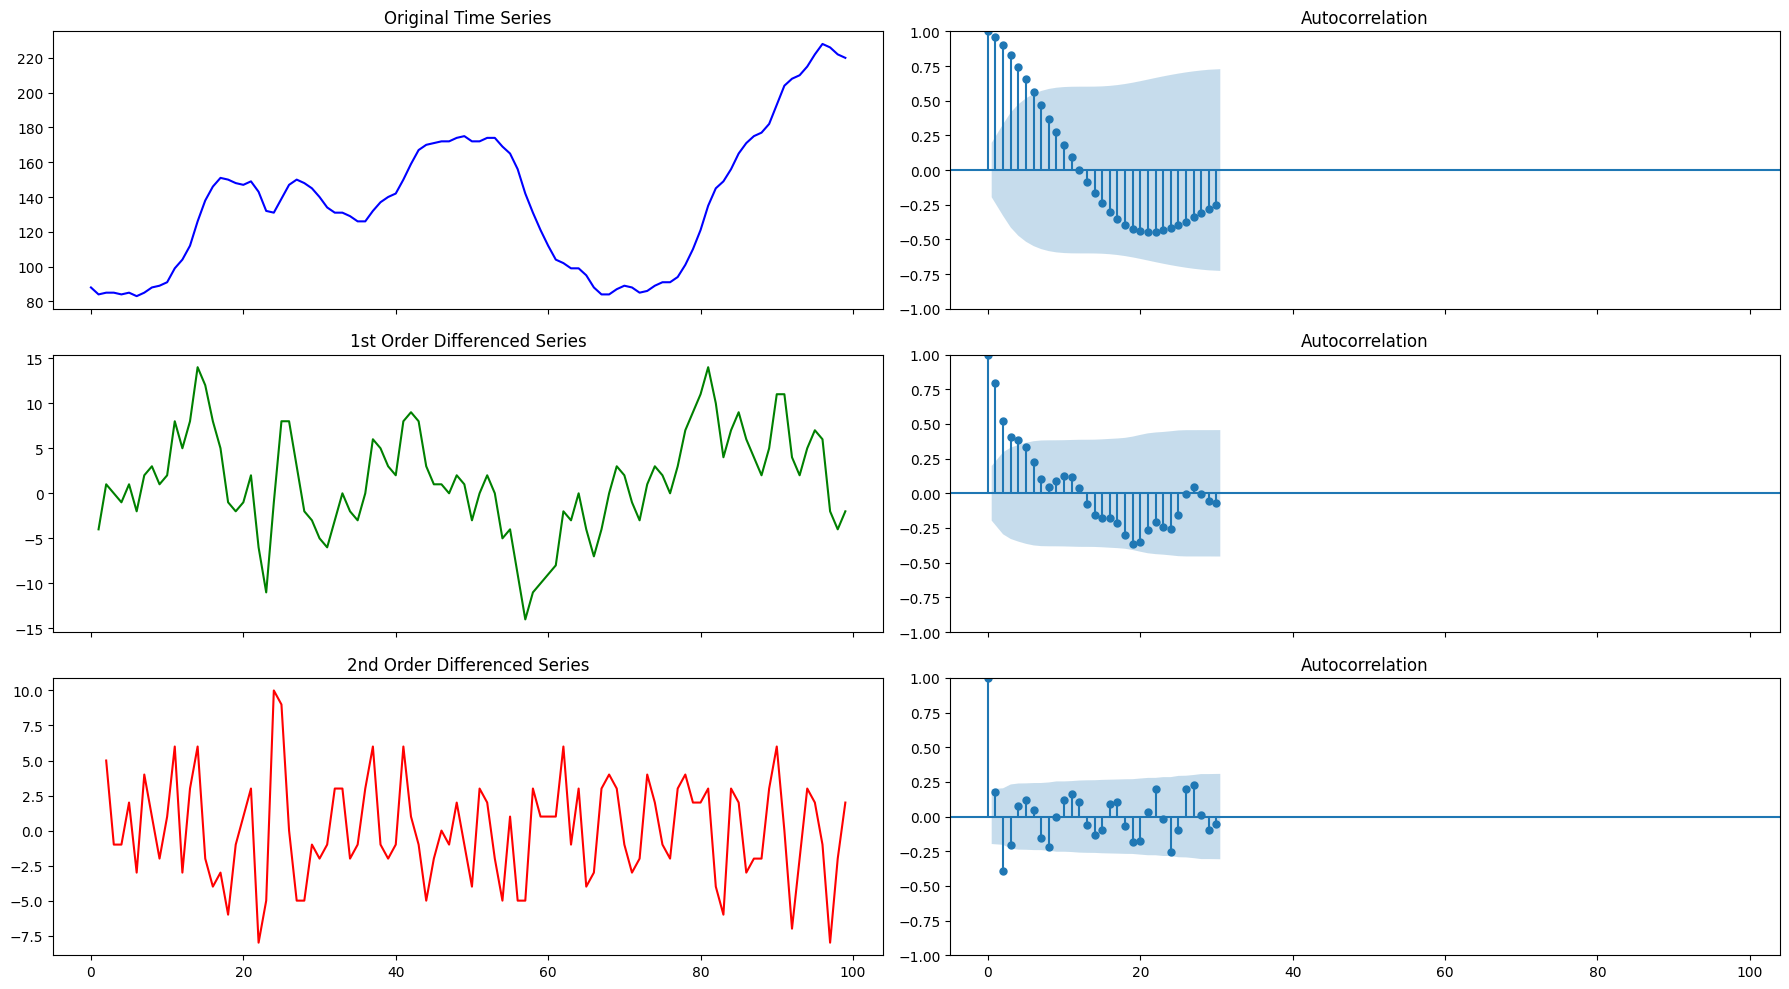

--- ADF Statistic for 1st Order Differencing ---
ADF Statistic: -2.722238
p-value: 0.070268
Critical Values:
	1%: -3.500
	5%: -2.892
	10%: -2.583

--- ADF Statistic for 2nd Order Differencing ---
ADF Statistic: -9.929762
p-value: 0.000000
Critical Values:
	1%: -3.500
	5%: -2.892
	10%: -2.583


In [4]:
plt.rcParams.update({'figure.figsize':(18,10), 'figure.dpi':100}) # Adjusted figure size and DPI

# Create subplots to visualize the original series, 1st differencing, and 2nd differencing
# Along with their respective Autocorrelation Function (ACF) plots
fig, axes = plt.subplots(3, 2, sharex=True)

# Plot Original Series and its ACF
axes[0, 0].plot(time_series_data.value, color='blue'); axes[0, 0].set_title('Original Time Series')
plot_acf(time_series_data.value, ax=axes[0, 1], lags=30) # Showing more lags

# Plot 1st Order Differencing and its ACF
# Differencing helps in making a non-stationary series stationary.
axes[1, 0].plot(time_series_data.value.diff(), color='green'); axes[1, 0].set_title('1st Order Differenced Series')
plot_acf(time_series_data.value.diff().dropna(), ax=axes[1, 1], lags=30)

# Plot 2nd Order Differencing and its ACF
axes[2, 0].plot(time_series_data.value.diff().diff(), color='red'); axes[2, 0].set_title('2nd Order Differenced Series')
plot_acf(time_series_data.value.diff().diff().dropna(), ax=axes[2, 1], lags=30)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

print('--- ADF Statistic for 1st Order Differencing ---')
# Perform ADF test on the 1st differenced series
adf_result_diff1 = adfuller(time_series_data.value.diff().dropna())
print('ADF Statistic: %f' % adf_result_diff1[0])
print('p-value: %f' % adf_result_diff1[1])
print('Critical Values:')
for key, value in adf_result_diff1[4].items():
    print('\t%s: %.3f' % (key, value))

print('\n--- ADF Statistic for 2nd Order Differencing ---')
# Perform ADF test on the 2nd differenced series
adf_result_diff2 = adfuller(time_series_data.value.diff().diff().dropna())
print('ADF Statistic: %f' % adf_result_diff2[0])
print('p-value: %f' % adf_result_diff2[1])
print('Critical Values:')
for key, value in adf_result_diff2[4].items():
    print('\t%s: %.3f' % (key, value))


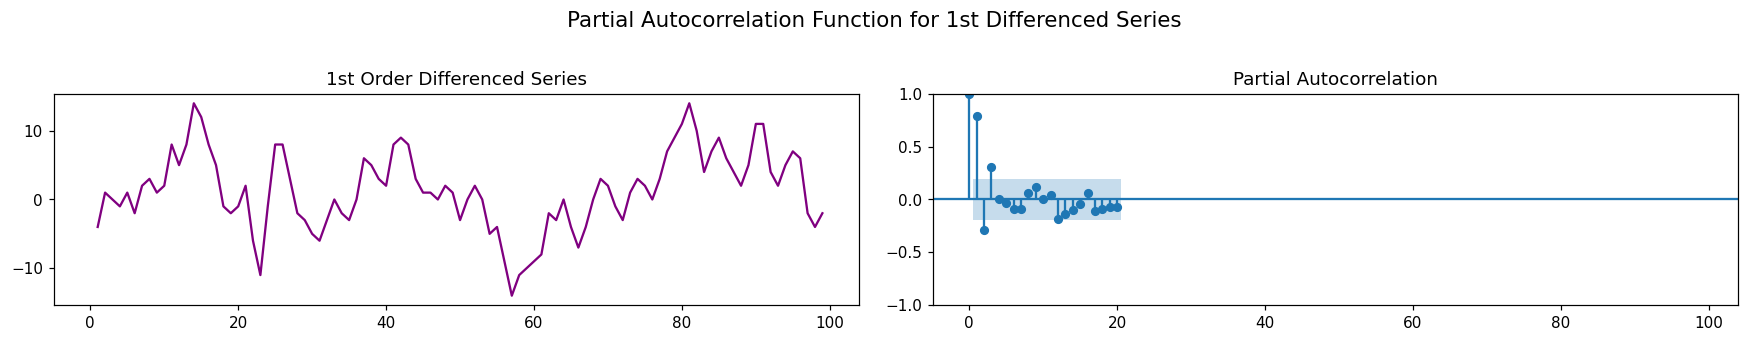

In [5]:
# PACF (Partial Autocorrelation Function) plot of the 1st differenced series
# The PACF helps in determining the 'p' (AR order) component of ARIMA.
plt.rcParams.update({'figure.figsize':(16,3), 'figure.dpi':110}) # Adjusted figure size and DPI

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(time_series_data.value.diff(), color='purple'); axes[0].set_title('1st Order Differenced Series')
axes[1].set(ylim=(-0.5, 1.0)) # Adjusted y-axis limit for PACF
plot_pacf(time_series_data.value.diff().dropna(), ax=axes[1], lags=20, method='ywm') # Added method and adjusted lags

plt.suptitle('Partial Autocorrelation Function for 1st Differenced Series', y=1.02, fontsize=14) # Added a main title
plt.tight_layout() # Adjust layout
plt.show()


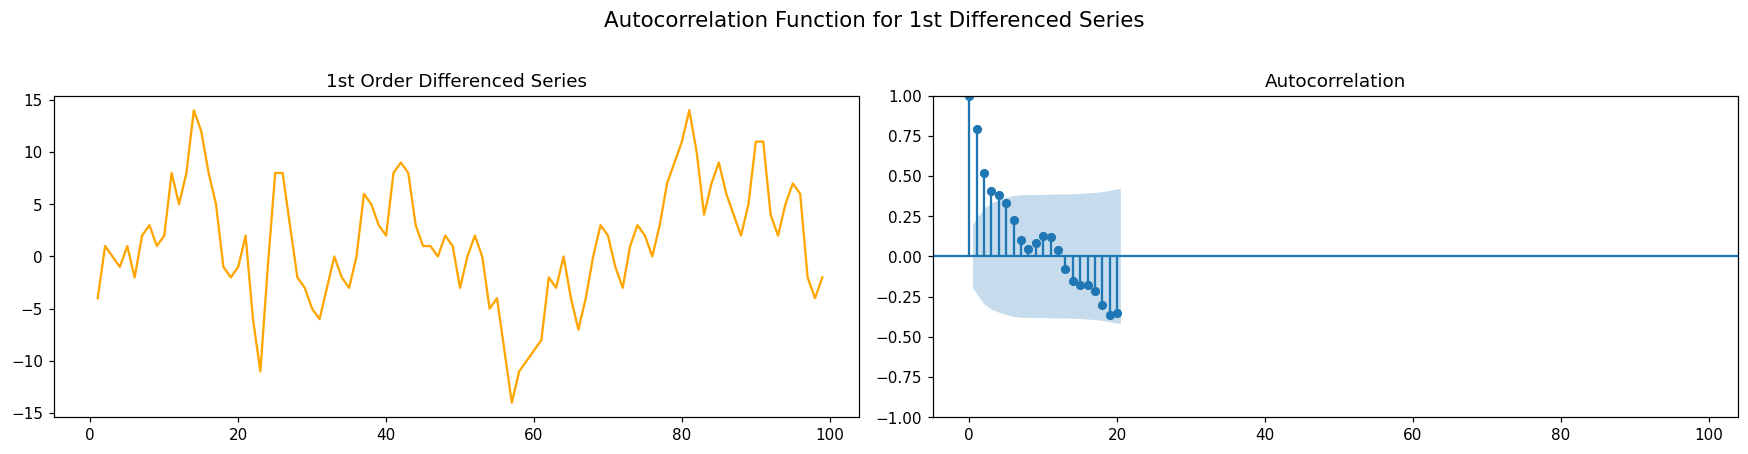

In [6]:
# ACF (Autocorrelation Function) plot of the 1st differenced series
# The ACF helps in determining the 'q' (MA order) component of ARIMA.
plt.rcParams.update({'figure.figsize':(16,4), 'figure.dpi':110}) # Adjusted figure size and DPI

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(time_series_data.value.diff(), color='orange'); axes[0].set_title('1st Order Differenced Series')
axes[1].set(ylim=(-0.2, 1.0)) # Adjusted y-axis limit for ACF
plot_acf(time_series_data.value.diff().dropna(), ax=axes[1], lags=20) # Adjusted lags

plt.suptitle('Autocorrelation Function for 1st Differenced Series', y=1.02, fontsize=14) # Added a main title
plt.tight_layout() # Adjust layout
plt.show()


In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Initialize and fit an ARIMA model with order (p=1, d=1, q=1)
# The 'order' parameter specifies (AR terms, differencing order, MA terms).
arima_model = ARIMA(time_series_data['value'], order=(1, 1, 1))
fitted_arima_model = arima_model.fit()

# Print the summary of the fitted ARIMA model, which includes coefficients, standard errors, p-values, and diagnostic checks.
print(fitted_arima_model.summary())



                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -254.150
Date:                Fri, 27 Mar 2026   AIC                            514.300
Time:                        17:51:47   BIC                            522.086
Sample:                             0   HQIC                           517.450
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6504      0.090      7.258      0.000       0.475       0.826
ma.L1          0.5256      0.088      5.994      0.000       0.354       0.697
sigma2         9.7934      1.405      6.970      0.0

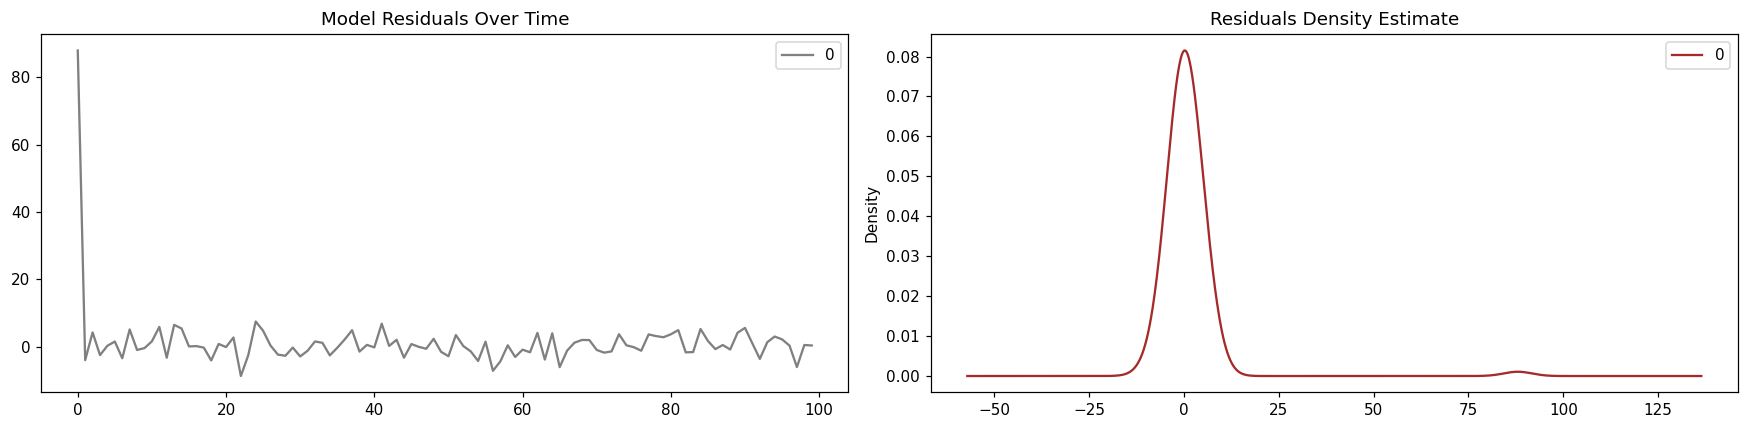

In [8]:
# Plot residual errors of the fitted ARIMA model
# Residuals should ideally be white noise (uncorrelated and normally distributed).
residuals = pd.DataFrame(fitted_arima_model.resid)

fig, ax = plt.subplots(1, 2, figsize=(16, 4)) # Adjusted figure size

# Plot of Residuals over Time
residuals.plot(title="Model Residuals Over Time", ax=ax[0], color='gray') # Changed title and color

# Density Plot of Residuals
residuals.plot(kind='kde', title='Residuals Density Estimate', ax=ax[1], color='brown') # Changed title and color

plt.tight_layout() # Adjust layout
plt.show()


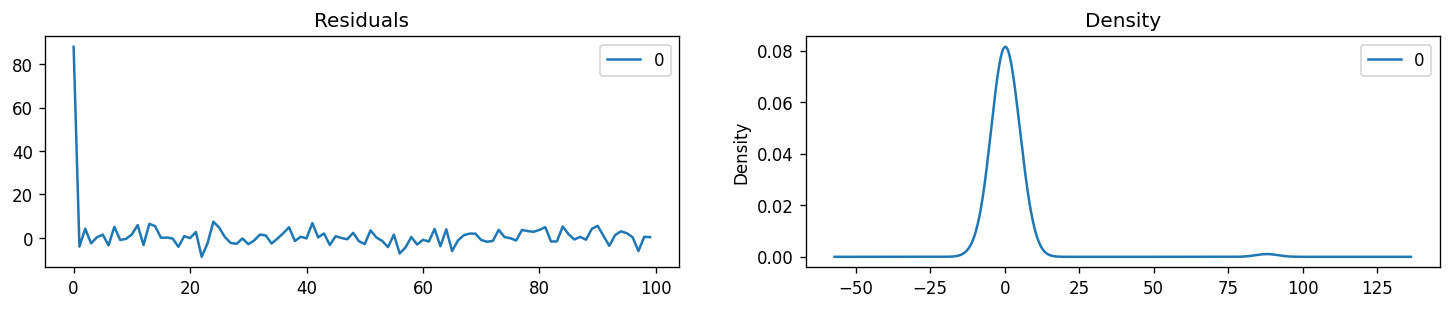

In [ ]:
# Plot residual errors
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2, figsize=(15,2.5))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

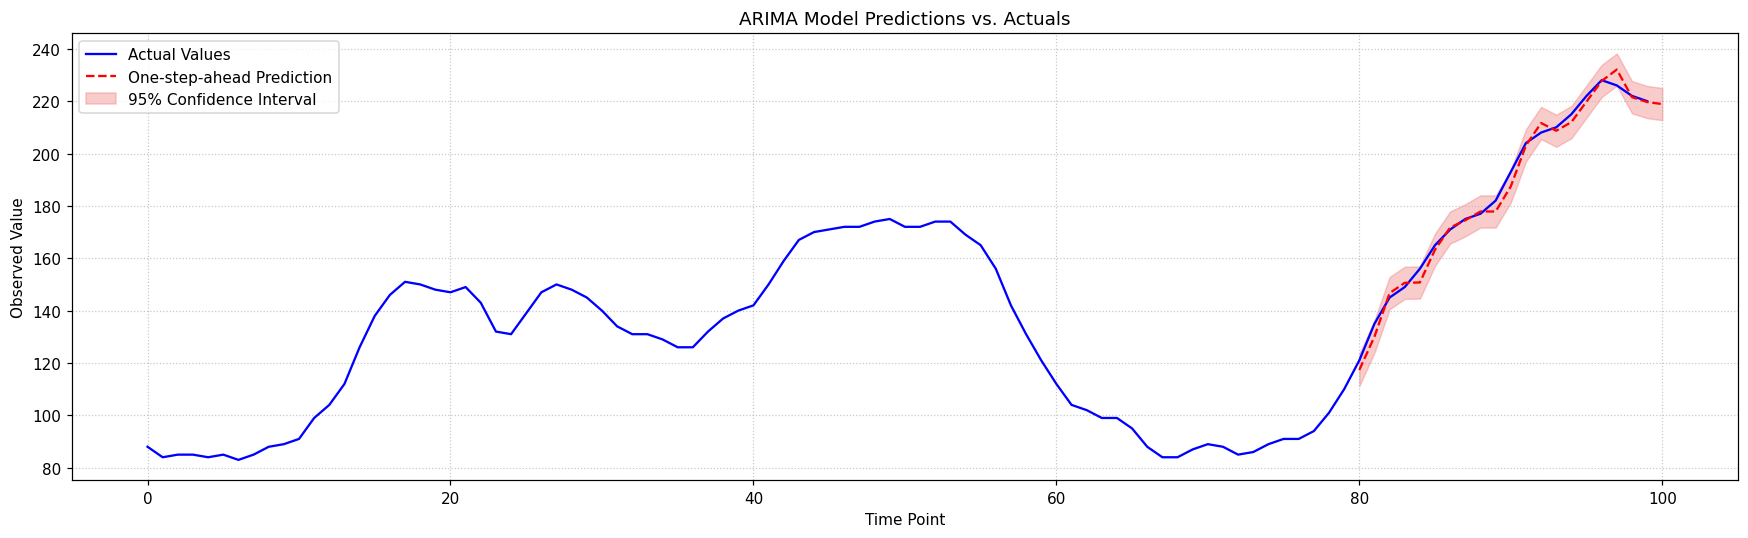

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5)) # Adjusted figure size

# Plot the original time series data as 'Actual' values
time_series_data['value'].plot(ax=ax, label='Actual Values', color='blue', linewidth=1.5)

# Get predictions from the fitted ARIMA model
# Predicting from a specific 'start' to 'end' index in the dataset.
prediction_output = fitted_arima_model.get_prediction(start=80, end=100, dynamic=False) # Changed start index and disabled dynamic prediction

# Extract predicted mean values
predicted_mean_values = prediction_output.predicted_mean

# Extract confidence intervals for the predictions
confidence_interval = prediction_output.conf_int()

# Plot the predicted values
ax.plot(predicted_mean_values.index, predicted_mean_values, label='One-step-ahead Prediction', color='red', linestyle='--', linewidth=1.5)

# Shade the confidence interval area
ax.fill_between(confidence_interval.index,
                confidence_interval.iloc[:, 0],
                confidence_interval.iloc[:, 1],
                color='lightcoral', alpha=0.4, label='95% Confidence Interval') # Changed color and label

ax.set_title('ARIMA Model Predictions vs. Actuals') # Added a more specific title
ax.set_xlabel('Time Point')
ax.set_ylabel('Observed Value')
ax.legend(loc='upper left') # Changed legend location
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


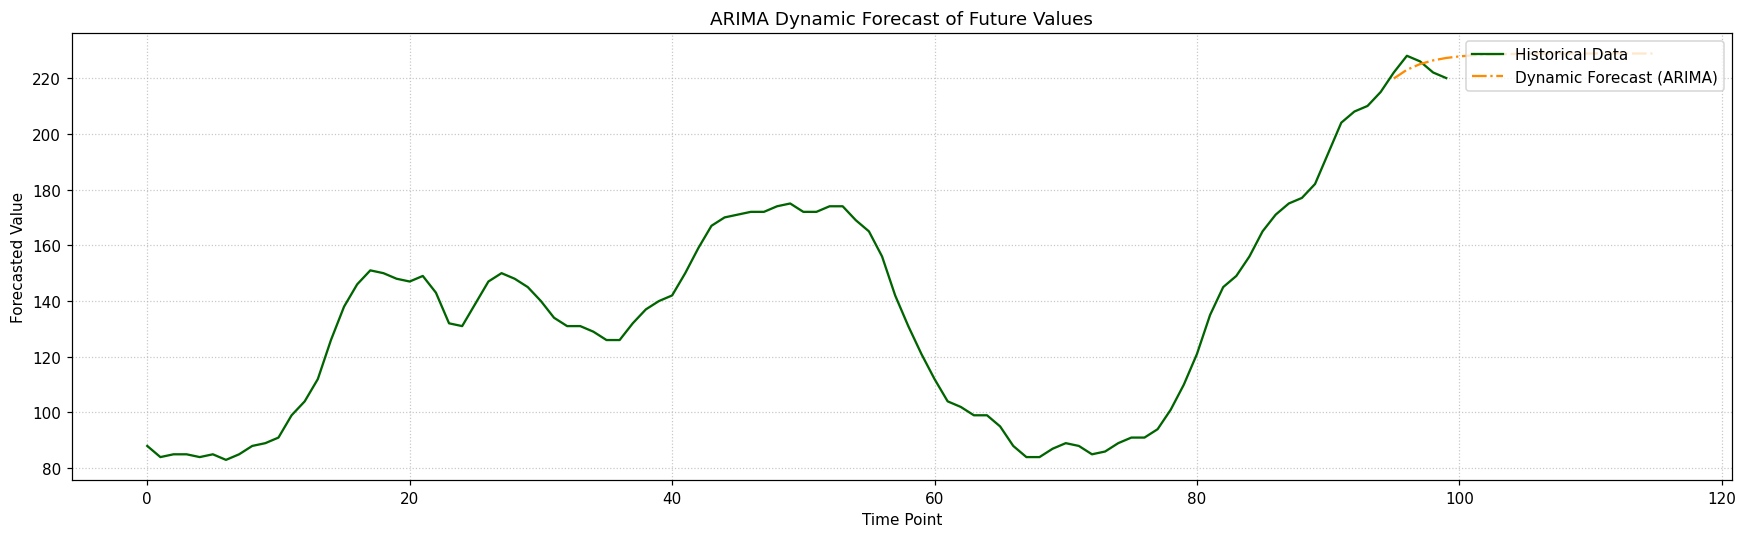

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5)) # Adjusted figure size

# Plot actual data from the time series
time_series_data['value'].plot(ax=ax, label='Historical Data', color='darkgreen', linewidth=1.5) # Changed label and color

# Get dynamic predictions (forecasting into the future beyond observed data)
# 'dynamic=True' means that previous forecasted values are used for subsequent forecasts.
dynamic_forecast = fitted_arima_model.get_prediction(start=95, end=115, dynamic=True) # Changed start and end for dynamic forecast

# Predicted values from the dynamic forecast
forecast_mean = dynamic_forecast.predicted_mean

# Plot the dynamic forecast
ax.plot(forecast_mean.index, forecast_mean, label='Dynamic Forecast (ARIMA)', linestyle='-.', color='darkorange', linewidth=1.5) # Changed label, linestyle and color

ax.set_title('ARIMA Dynamic Forecast of Future Values') # Changed title
ax.set_xlabel('Time Point')
ax.set_ylabel('Forecasted Value')
ax.legend(loc='upper right') # Changed legend location
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


In [12]:
# Helper function to create a differenced series
def generate_differenced_series(data_array, interval_val=1):
    differenced_data = list()
    for i in range(interval_val, len(data_array)):
        current_value = data_array[i] - data_array[i - interval_val]
        differenced_data.append(current_value)
    return np.array(differenced_data)

# Helper function to invert a differenced value back to its original scale
def invert_differenced_value(history_data, differenced_prediction, interval_val=1):
    return differenced_prediction + history_data[-interval_val]

# Function to evaluate an ARIMA model for a given order (p,d,q) and return Mean Absolute Error (MAE)
def evaluate_arima_model(time_series_data_input, arima_config_order, train_split_ratio=None):
    # Ensure data is float type
    time_series_data_input = time_series_data_input.astype('float32')

    # Determine training set size
    if train_split_ratio is None:
        train_set_size = int(len(time_series_data_input) * 0.60) # Changed default train split from 0.50 to 0.60
    else:
        train_set_size = int(train_split_ratio)

    train_series, test_series = time_series_data_input[0:train_set_size], time_series_data_input[train_set_size:]
    historical_observations = [x for x in train_series]

    # Make predictions for the test set
    model_predictions = list()
    for t_step in range(len(test_series)):
        # Difference the historical data for model fitting
        differenced_data_for_model = generate_differenced_series(historical_observations, 1)

        # Fit ARIMA model on differenced data
        arima_model_instance = ARIMA(differenced_data_for_model, order=arima_config_order)
        fitted_model_instance = arima_model_instance.fit(trend='nc', disp=0)

        # Get one-step-ahead forecast from the fitted model
        current_predicted_value_diff = fitted_model_instance.forecast()[0]

        # Invert the differenced prediction to the original scale
        current_predicted_value_original = invert_differenced_value(historical_observations, current_predicted_value_diff, 1)
        model_predictions.append(current_predicted_value_original)

        # Add the actual observation from the test set to history for the next prediction
        historical_observations.append(test_series[t_step])

    # Calculate Mean Absolute Error (MAE) for the predictions
    mean_abs_error = mean_absolute_error(test_series, model_predictions)
    return mean_abs_error


# Function to evaluate combinations of p, d, and q values for an ARIMA model
def evaluate_arima_orders(dataset_input, p_candidate_values, d_candidate_values, q_candidate_values):
    dataset_input = dataset_input.astype('float32')
    best_error_score, best_arima_configuration = float("inf"), None

    # Iterate through all combinations of p, d, q values
    for p_val in p_candidate_values:
        for d_val in d_candidate_values:
            for q_val in q_candidate_values:
                current_order = (p_val, d_val, q_val)
                try:
                    current_mae = evaluate_arima_model(dataset_input, current_order)
                    # Update best configuration if current model performs better
                    if current_mae < best_error_score:
                        best_error_score, best_arima_configuration = current_mae, current_order
                    print('ARIMA%s MAE=%.3f' % (current_order, current_mae))
                except Exception as e: # Catch any errors during model evaluation for a specific order
                    # print(f'Could not evaluate ARIMA{current_order}: {e}') # Uncomment for detailed error messages
                    continue
    print('Best ARIMA%s MAE=%.3f' % (best_arima_configuration, best_error_score))
